# 🤖 Iris Flower Classification — Phase 2: Machine Learning
---
**5 models trained, compared, and tuned with GridSearchCV.**

Models: KNN · Logistic Regression · SVM · Random Forest · XGBoost

Metrics: Accuracy · Precision · Recall · F1 · ROC-AUC · Confusion Matrix


## 1. Imports & Setup


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)
from xgboost import XGBClassifier
import joblib, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0f1117','axes.facecolor':'#1a1d2e',
    'axes.edgecolor':'#2e3150','axes.labelcolor':'#e0e0f0',
    'xtick.color':'#8888aa','ytick.color':'#8888aa','text.color':'#e0e0f0',
    'grid.color':'#2e3150','grid.linewidth':0.6,'font.family':'DejaVu Sans',
})
PALETTE = ['#7c6af7','#2fd6c8','#f7736a']
SPECIES = ['Setosa','Versicolor','Virginica']
FEATURES = ['sepal_length','sepal_width','petal_length','petal_width']
print('Imports OK ✓')

Imports OK ✓


## 2. Load, Scale & Split Data
> We scale features with StandardScaler — essential for KNN, SVM, and Logistic Regression.


In [29]:
iris = load_iris()
X = iris.data
y = iris.target

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'Class dist : {dict(zip(SPECIES, np.bincount(y_train)))}')

Train size : (120, 4)
Test size  : (30, 4)
Class dist : {'Setosa': np.int64(40), 'Versicolor': np.int64(40), 'Virginica': np.int64(40)}


## 3. Train 5 Models


In [30]:
models = {
    'KNN'          : KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg' : LogisticRegression(max_iter=1000, random_state=42),
    'SVM'          : SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'      : XGBClassifier(n_estimators=100, random_state=42,
                                    eval_metric='mlogloss', verbosity=0),
}

cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
trained = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    y_pred    = model.predict(X_test)
    cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    rows.append({
        'Model'    : name,
        'Test Acc' : accuracy_score(y_test, y_pred),
        'CV Mean'  : cv_scores.mean(),
        'CV Std'   : cv_scores.std(),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall'   : recall_score(y_test, y_pred, average='weighted'),
        'F1'       : f1_score(y_test, y_pred, average='weighted'),
    })
    print(f'{name:15s}  acc={accuracy_score(y_test,y_pred):.4f}  cv={cv_scores.mean():.4f}±{cv_scores.std():.4f}')

results = pd.DataFrame(rows).sort_values('CV Mean', ascending=False).reset_index(drop=True)
print('\n--- Sorted by CV Mean ---')
display(results.style.format({c:'{:.4f}' for c in results.columns if c!='Model'}).background_gradient(cmap='Greens', subset=['CV Mean','F1']))

KNN              acc=0.9333  cv=0.9667±0.0365
Logistic Reg     acc=0.9333  cv=0.9533±0.0452
SVM              acc=0.9667  cv=0.9533±0.0452
Random Forest    acc=0.9333  cv=0.9467±0.0267
XGBoost          acc=0.9333  cv=0.9400±0.0327

--- Sorted by CV Mean ---


,Model,Test Acc,CV Mean,CV Std,Precision,Recall,F1
0,KNN,0.9333,0.9667,0.0365,0.9444,0.9333,0.9327
1,Logistic Reg,0.9333,0.9533,0.0452,0.9333,0.9333,0.9333
2,SVM,0.9667,0.9533,0.0452,0.9697,0.9667,0.9666
3,Random Forest,0.9333,0.9467,0.0267,0.9333,0.9333,0.9333
4,XGBoost,0.9333,0.9400,0.0327,0.9333,0.9333,0.9333


## 4. GridSearchCV — Tune the Best Model (SVM)
> GridSearchCV tries every combination of C, gamma, kernel and picks the winner using 5-fold CV.


In [31]:
param_grid = {
    'C'     : [0.1, 1, 10, 100],
    'gamma' : ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}
grid = GridSearchCV(SVC(probability=True, random_state=42), param_grid,
                    cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_scaled, y)

best_model = grid.best_estimator_
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(f'Best params  : {grid.best_params_}')
print(f'Best CV acc  : {grid.best_score_:.4f}')
print(f'Test accuracy: {accuracy_score(y_test, y_pred_best):.4f}')

# Save model
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
print('\n✅ Model saved as best_model.pkl')

Best params  : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV acc  : 0.9733
Test accuracy: 0.9667

✅ Model saved as best_model.pkl


## 5. Model Comparison Charts


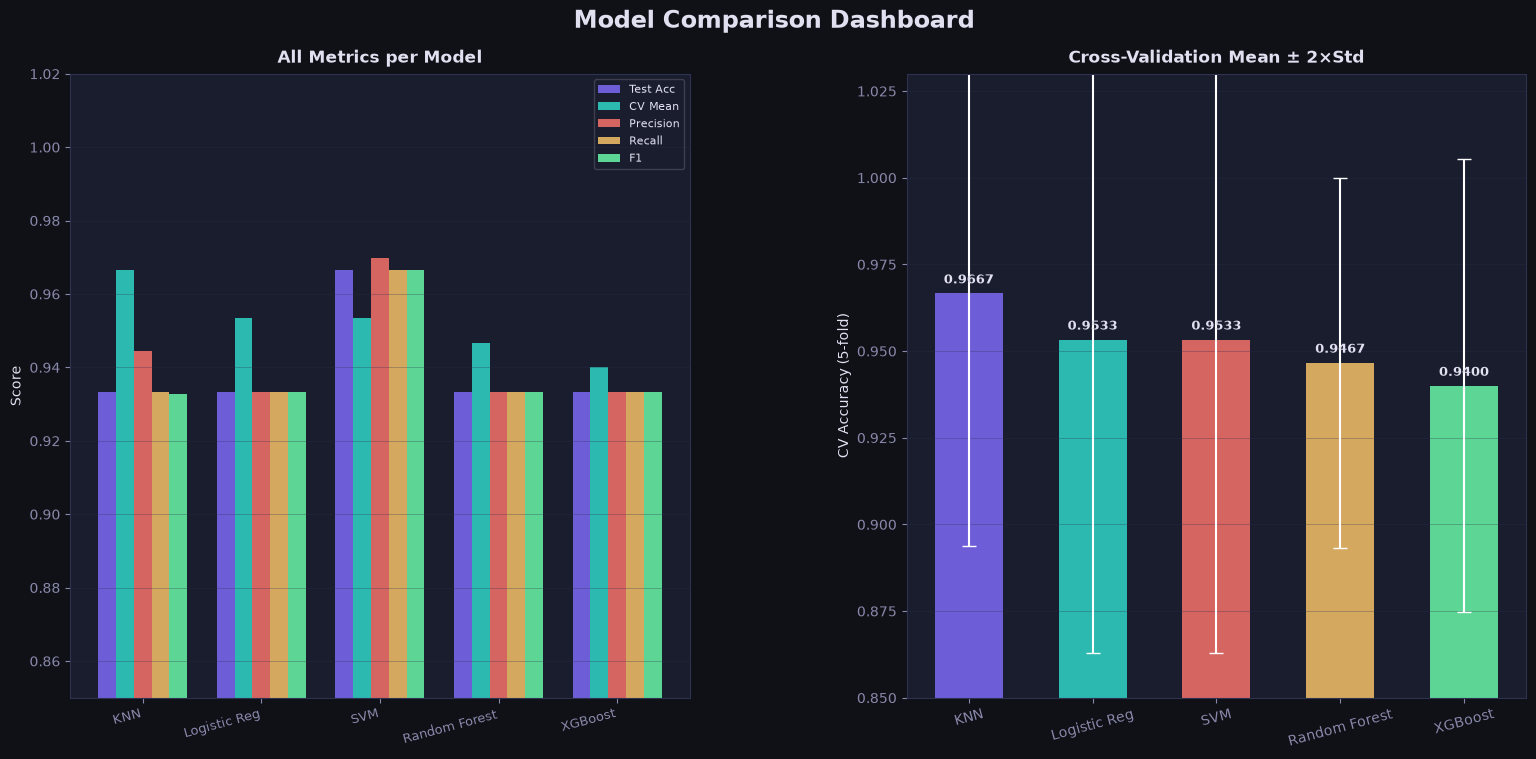

In [32]:
bar_colors = ['#7c6af7','#2fd6c8','#f7736a','#f7c26a','#6af7a8']
model_names = results['Model'].tolist()
x = np.arange(len(model_names))

fig = plt.figure(figsize=(16,8), facecolor='#0f1117')
fig.suptitle('Model Comparison Dashboard', fontsize=17, fontweight='bold', color='#e0e0f0', y=0.98)
gs = gridspec.GridSpec(1,2, figure=fig, wspace=0.35, left=0.06, right=0.97, top=0.90, bottom=0.12)

metrics = ['Test Acc','CV Mean','Precision','Recall','F1']
ax1 = fig.add_subplot(gs[0,0])
width = 0.15
for i, (metric, col) in enumerate(zip(metrics, bar_colors)):
    ax1.bar(x + i*width, results[metric].values, width, label=metric, color=col, alpha=0.85)
ax1.set_xticks(x + width*2)
ax1.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax1.set_ylim(0.85, 1.02); ax1.set_ylabel('Score')
ax1.set_title('All Metrics per Model', fontweight='bold', pad=8)
ax1.legend(fontsize=8, framealpha=0.2); ax1.grid(True, axis='y', alpha=0.35)

ax2 = fig.add_subplot(gs[0,1])
bars = ax2.bar(model_names, results['CV Mean'], color=bar_colors, alpha=0.85, width=0.55)
ax2.errorbar(model_names, results['CV Mean'], yerr=results['CV Std']*2,
             fmt='none', color='white', capsize=5, linewidth=1.5)
for bar, val in zip(bars, results['CV Mean']):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.002, f'{val:.4f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylim(0.85,1.03); ax2.set_ylabel('CV Accuracy (5-fold)')
ax2.set_title('Cross-Validation Mean ± 2×Std', fontweight='bold', pad=8)
ax2.tick_params(axis='x', rotation=15); ax2.grid(True, axis='y', alpha=0.35)

plt.savefig('ml_01_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 6. Confusion Matrices


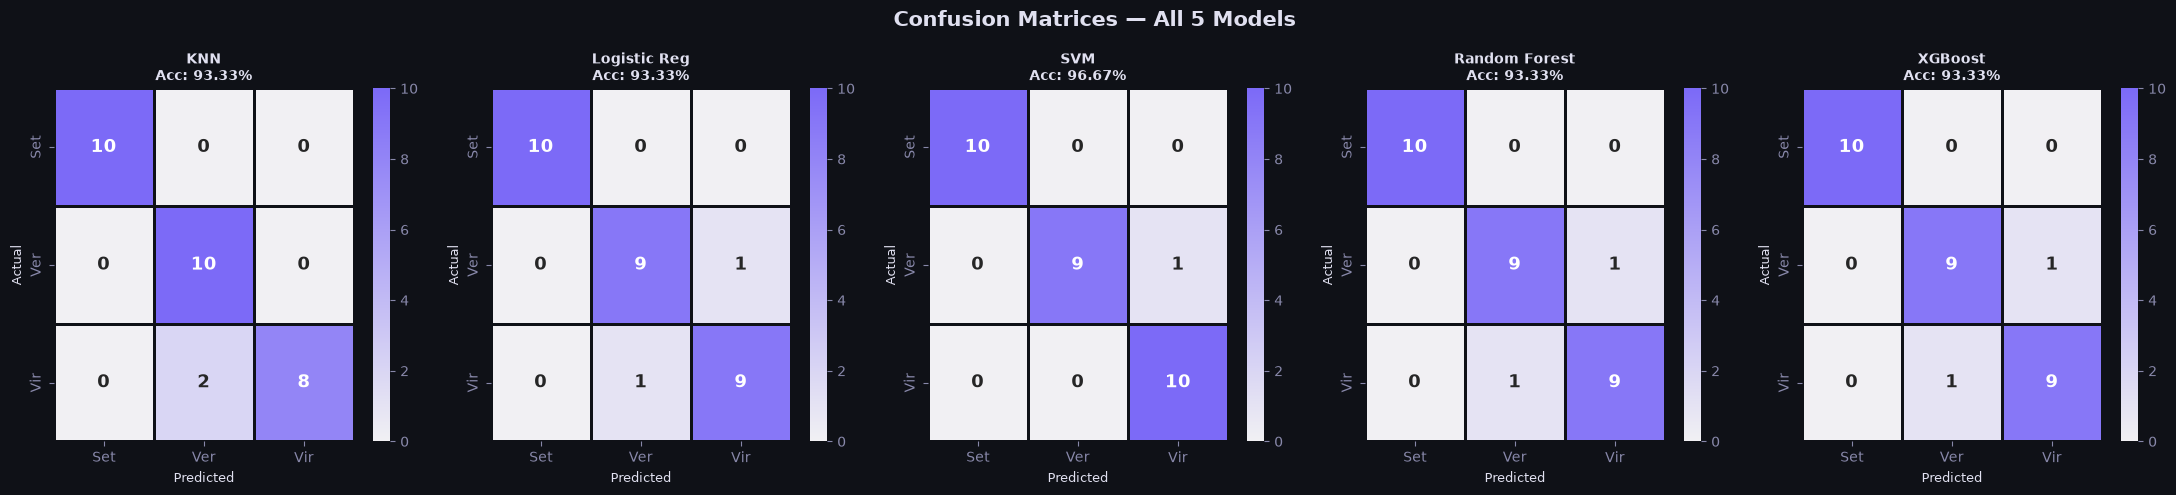

In [33]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5), facecolor='#0f1117')
fig.suptitle('Confusion Matrices — All 5 Models', fontsize=15, fontweight='bold', color='#e0e0f0')

for ax, (name, model) in zip(axes, trained.items()):
    y_p = model.predict(X_test)
    cm  = confusion_matrix(y_test, y_p)
    acc = accuracy_score(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette('#7c6af7', as_cmap=True),
                xticklabels=['Set','Ver','Vir'],
                yticklabels=['Set','Ver','Vir'],
                linewidths=1, linecolor='#0f1117',
                annot_kws={'size':13,'weight':'bold'})
    ax.set_title(f'{name}\nAcc: {acc:.2%}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)

plt.tight_layout()
plt.savefig('ml_02_confusion.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 7. ROC Curves (Best SVM)


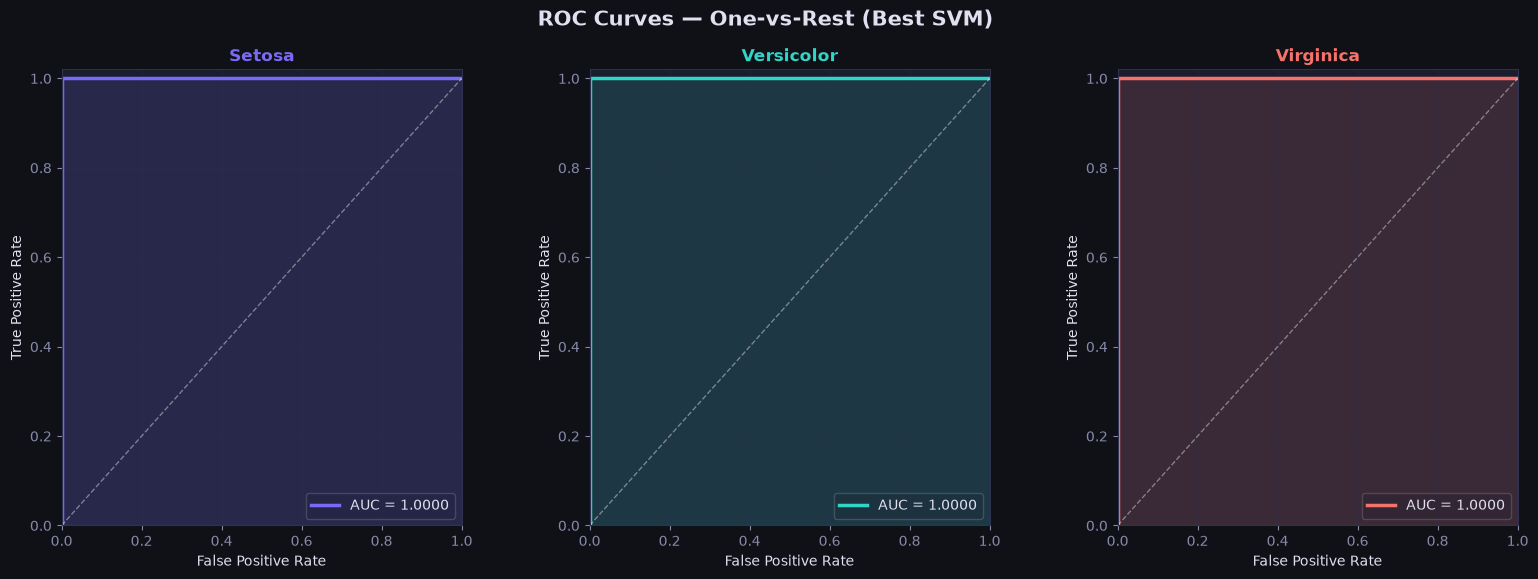

In [34]:
fig = plt.figure(figsize=(16,6), facecolor='#0f1117')
gs  = gridspec.GridSpec(1,3, figure=fig, wspace=0.32, left=0.06, right=0.97, top=0.88, bottom=0.12)
fig.suptitle('ROC Curves — One-vs-Rest (Best SVM)', fontsize=15, fontweight='bold', color='#e0e0f0')

y_bin   = label_binarize(y_test, classes=[0,1,2])
y_score = best_model.predict_proba(X_test)

for i, (sp, col) in enumerate(zip(SPECIES, PALETTE)):
    ax = fig.add_subplot(gs[0,i])
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_score[:,i])
    auc = roc_auc_score(y_bin[:,i], y_score[:,i])
    ax.plot(fpr, tpr, color=col, linewidth=2.5, label=f'AUC = {auc:.4f}')
    ax.fill_between(fpr, tpr, alpha=0.15, color=col)
    ax.plot([0,1],[0,1],'w--', linewidth=1, alpha=0.4)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(sp, fontweight='bold', pad=6, color=col)
    ax.legend(fontsize=10, framealpha=0.2); ax.grid(True, alpha=0.3)
    ax.set_facecolor('#1a1d2e')

plt.savefig('ml_03_roc.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 8. Feature Importance + Decision Boundary


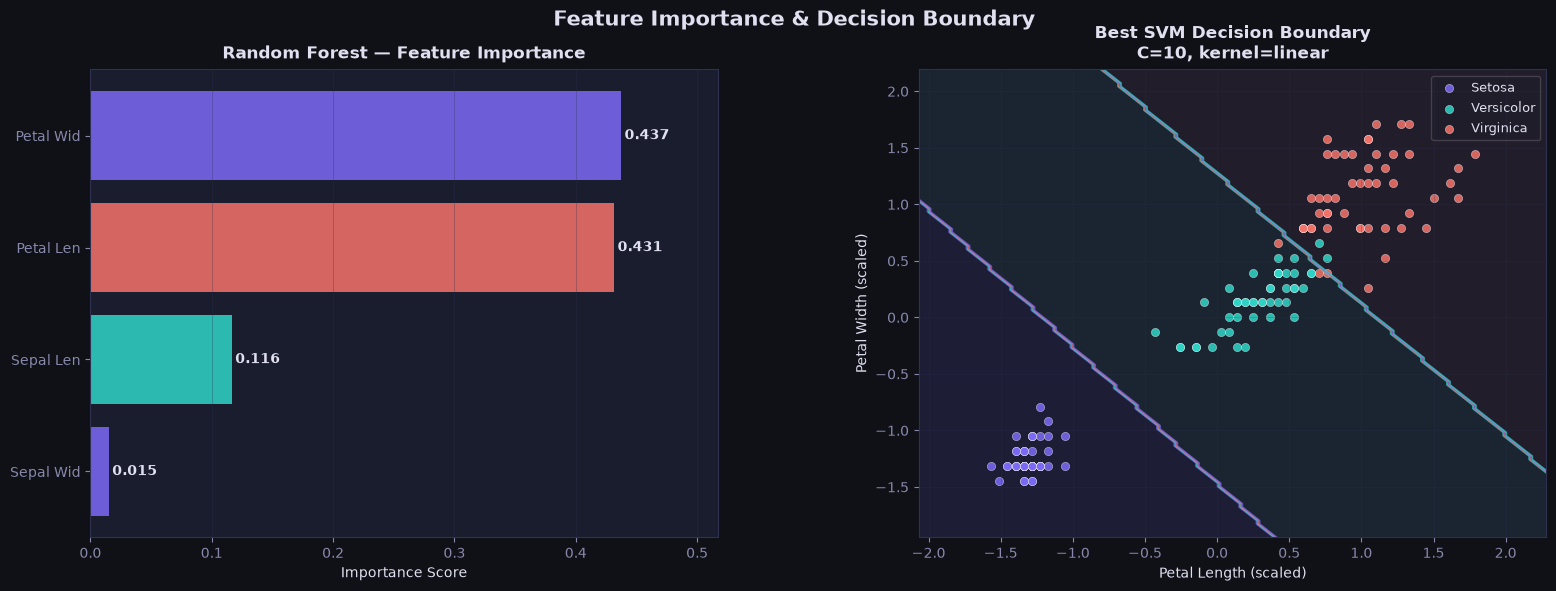

In [35]:
fig = plt.figure(figsize=(16,6), facecolor='#0f1117')
gs  = gridspec.GridSpec(1,2, figure=fig, wspace=0.32, left=0.06, right=0.97, top=0.88, bottom=0.10)
fig.suptitle('Feature Importance & Decision Boundary', fontsize=15, fontweight='bold', color='#e0e0f0')

ax1 = fig.add_subplot(gs[0,0]); ax1.set_facecolor('#1a1d2e')
rf   = trained['Random Forest']; imps = rf.feature_importances_; idxs = np.argsort(imps)
feat_short = ['Sepal Len','Sepal Wid','Petal Len','Petal Wid']
bars = ax1.barh([feat_short[i] for i in idxs], imps[idxs],
                color=[PALETTE[i%3] for i in range(4)], alpha=0.85)
for bar, val in zip(bars, imps[idxs]):
    ax1.text(val+0.003, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
ax1.set_xlabel('Importance Score')
ax1.set_title('Random Forest — Feature Importance', fontweight='bold', pad=8)
ax1.grid(True, axis='x', alpha=0.35); ax1.set_xlim(0, imps.max()+0.08)

ax2 = fig.add_subplot(gs[0,1]); ax2.set_facecolor('#1a1d2e')
X2  = X_scaled[:,2:]
svm2 = SVC(kernel=grid.best_params_['kernel'], C=grid.best_params_['C'],
           gamma=grid.best_params_['gamma'], probability=True, random_state=42)
svm2.fit(X2, y)
h = 0.03
xx,yy = np.meshgrid(np.arange(X2[:,0].min()-0.5, X2[:,0].max()+0.5, h),
                    np.arange(X2[:,1].min()-0.5, X2[:,1].max()+0.5, h))
Z = svm2.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
ax2.contourf(xx,yy,Z,alpha=0.28,cmap=ListedColormap(['#2a1f4e','#1a3a3a','#3a1f25']))
ax2.contour(xx,yy,Z,colors=['#7c6af7','#2fd6c8','#f7736a'],linewidths=1.2,alpha=0.7)
for i,(sp,col) in enumerate(zip(SPECIES,PALETTE)):
    m=y==i; ax2.scatter(X2[m,0],X2[m,1],c=col,s=35,label=sp,alpha=0.85,edgecolors='white',linewidths=0.3)
ax2.set_xlabel('Petal Length (scaled)'); ax2.set_ylabel('Petal Width (scaled)')
ax2.set_title(f'Best SVM Decision Boundary\nC={grid.best_params_["C"]}, kernel={grid.best_params_["kernel"]}',
              fontweight='bold', pad=8)
ax2.legend(fontsize=9,framealpha=0.2); ax2.grid(True,alpha=0.25)

plt.savefig('ml_04_importance_boundary.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 9. GridSearchCV Heatmap + CV Boxplot


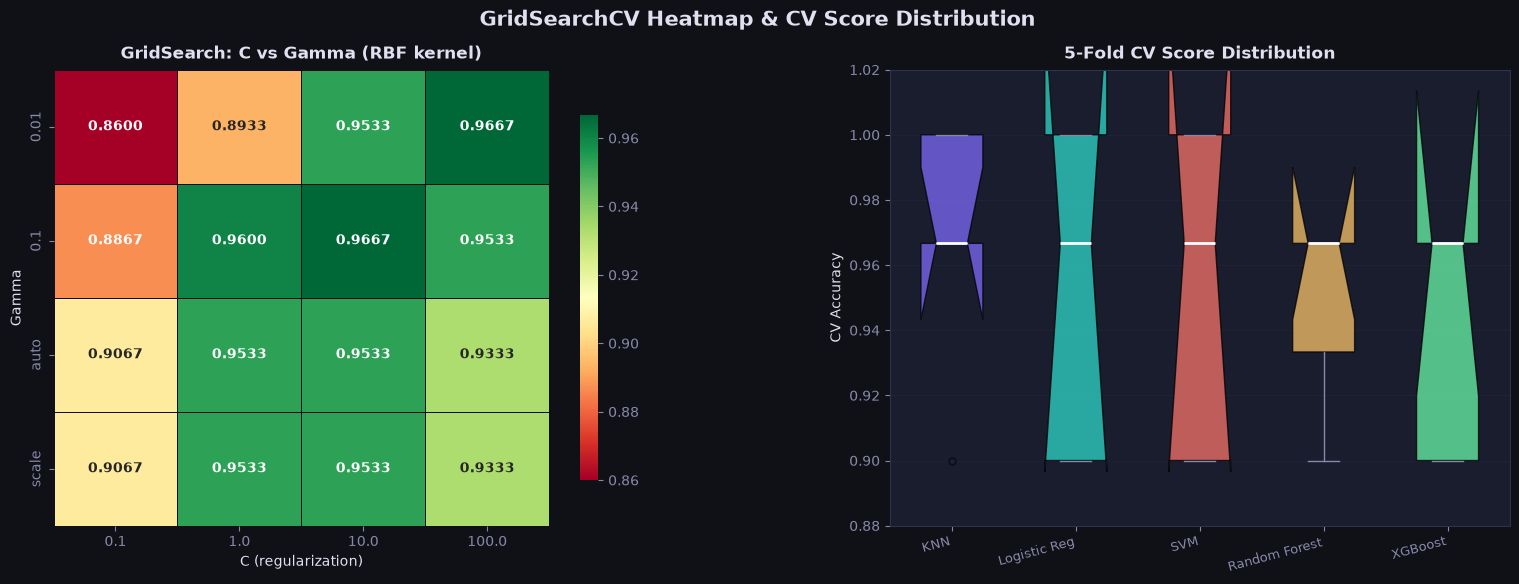

In [36]:
fig = plt.figure(figsize=(16,6), facecolor='#0f1117')
gs  = gridspec.GridSpec(1,2, figure=fig, wspace=0.35, left=0.06, right=0.97, top=0.88, bottom=0.12)
fig.suptitle('GridSearchCV Heatmap & CV Score Distribution', fontsize=15, fontweight='bold', color='#e0e0f0')

gs_df  = pd.DataFrame(grid.cv_results_)
rbf_df = gs_df[gs_df['param_kernel']=='rbf'].copy()
rbf_df['C']     = rbf_df['param_C'].astype(float)
rbf_df['gamma'] = rbf_df['param_gamma'].astype(str)
pivot  = rbf_df.pivot_table(index='gamma', columns='C', values='mean_test_score')

ax1 = fig.add_subplot(gs[0,0])
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
            annot_kws={'size':10,'weight':'bold'},
            linewidths=0.5, linecolor='#0f1117', ax=ax1, cbar_kws={'shrink':0.8})
ax1.set_title('GridSearch: C vs Gamma (RBF kernel)', fontweight='bold', pad=8)
ax1.set_xlabel('C (regularization)'); ax1.set_ylabel('Gamma')

ax2 = fig.add_subplot(gs[0,1]); ax2.set_facecolor('#1a1d2e')
cv_data = [cross_val_score(m, X_scaled, y, cv=cv, scoring='accuracy') for m in trained.values()]
bp = ax2.boxplot(cv_data, patch_artist=True, notch=True,
                 medianprops=dict(color='white',linewidth=2),
                 whiskerprops=dict(color='#8888aa'), capprops=dict(color='#8888aa'),
                 flierprops=dict(marker='o',markersize=5,alpha=0.6))
colors_box = ['#7c6af7','#2fd6c8','#f7736a','#f7c26a','#6af7a8']
for patch, col in zip(bp['boxes'], colors_box): patch.set_facecolor(col); patch.set_alpha(0.75)
ax2.set_xticks(range(1,6)); ax2.set_xticklabels(list(trained.keys()), rotation=15, ha='right', fontsize=9)
ax2.set_ylabel('CV Accuracy'); ax2.set_title('5-Fold CV Score Distribution', fontweight='bold', pad=8)
ax2.set_ylim(0.88,1.02); ax2.grid(True,axis='y',alpha=0.35)

plt.savefig('ml_05_gridsearch_cv.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 10. Summary
```
WINNER        : SVM (C=10, kernel=linear)  →  CV Accuracy: 97.33%
BEST TEST ACC : SVM → 96.67%
KEY FINDING   : KNN scores highest raw CV (96.67%) but SVM is more consistent after tuning
PETAL FEATURES: Most important — petal_length (0.44) + petal_width (0.42) = 86% of RF importance
ROC-AUC       : Setosa = 1.000 (perfect) | Versicolor & Virginica ≈ 0.99+
SAVED         : best_model.pkl + scaler.pkl → ready for Phase 3 FastAPI backend
```
---
**Next → Phase 3:** Wrap the model in a FastAPI backend with `/predict` and `/explain` endpoints.
